# Lista 12 — GQA: IMDB Sentiment Classification

Eksperymenty z Grouped Query Attention na zbiorze IMDB.

**Źródło:** Ainslie et al., *GQA: Training Generalized Multi-Query Transformer Models from Multi-Head Checkpoints*, EMNLP 2023. https://arxiv.org/abs/2305.13245

**Eksperymenty:**
1. Siatka H×G (10 kombinacji × 3 seedy)
2. Długość sekwencji × G (H=8 fixed)
3. Layer-wise GQA
4. Similarity-based grouping — TODO (po wynikach siatki)

## 0. Instalacja

## 1. Importy i konfiguracja

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import time
import math
import random
import os
from collections import Counter, defaultdict
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: NVIDIA GeForce GTX 1080
VRAM: 8.6 GB


## 2. MLflow setup

In [4]:
import os
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'
mlflow.set_tracking_uri('./mlruns')
mlflow.set_experiment('GQA_IMDB')

2026/06/07 15:17:06 INFO mlflow.tracking.fluent: Experiment with name 'GQA_IMDB' does not exist. Creating a new experiment.


<Experiment: artifact_location='/home/mikol/ai_studies/Deep-Neural-Networks-PWR/lab12/mlruns/911338561186862259', creation_time=1780838226406, effective_trace_archival_retention=None, experiment_id='911338561186862259', last_update_time=1780838226406, lifecycle_stage='active', name='GQA_IMDB', tags={}, trace_location=None, workspace='default'>

## 3. Dane — IMDB

In [6]:
dataset = load_dataset('imdb')
print(dataset)

def tokenize(text):
    return text.lower().split()

counter = Counter()
for ex in dataset['train']:
    counter.update(tokenize(ex['text']))

VOCAB_SIZE = 10000
vocab = ['<PAD>', '<UNK>', '<CLS>'] + [w for w, _ in counter.most_common(VOCAB_SIZE - 3)]
word2idx = {w: i for i, w in enumerate(vocab)}
PAD_IDX = word2idx['<PAD>']
UNK_IDX = word2idx['<UNK>']
CLS_IDX = word2idx['<CLS>']
NUM_CLASSES = 2
print(f'Vocab size: {len(vocab)}, NUM_CLASSES: {NUM_CLASSES}')

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
Vocab size: 10000, NUM_CLASSES: 2


In [7]:
class IMDBDataset(Dataset):
    def __init__(self, split, max_length=256):
        self.data = dataset[split]
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def encode(self, text):
        tokens = tokenize(text)[:self.max_length - 1]
        ids = [CLS_IDX] + [word2idx.get(t, UNK_IDX) for t in tokens]
        ids += [PAD_IDX] * (self.max_length - len(ids))
        return ids[:self.max_length]

    def __getitem__(self, idx):
        ex = self.data[idx]
        return (torch.tensor(self.encode(ex['text']), dtype=torch.long),
                torch.tensor(ex['label'], dtype=torch.long))


def get_loaders(max_length=256, batch_size=64):
    train_loader = DataLoader(IMDBDataset('train', max_length), batch_size=batch_size,
                              shuffle=True,  num_workers=2, pin_memory=True)
    test_loader  = DataLoader(IMDBDataset('test',  max_length), batch_size=batch_size,
                              shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, test_loader

# test
_tl, _vl = get_loaders()
_x, _y = next(iter(_tl))
print(f'Batch: x={_x.shape}, y={_y.shape}')

Batch: x=torch.Size([64, 256]), y=torch.Size([64])


## 4. GQA — implementacja

In [8]:
class GroupedQueryAttention(nn.Module):
    """
    Grouped Query Attention (Ainslie et al., EMNLP 2023).

    d_model   : wymiar modelu
    num_heads : liczba głowic Q (H)
    num_groups: liczba grup K,V (G). G=H → MHA, G=1 → MQA
    group_assignment: lista len=H z wartościami in [0, G-1].
                      None = naiwne sąsiednie grupowanie.
    """
    def __init__(self, d_model, num_heads, num_groups, group_assignment=None, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        assert num_groups <= num_heads
        if group_assignment is None:
            assert num_heads % num_groups == 0, 'num_heads musi być podzielny przez num_groups'

        self.num_heads  = num_heads
        self.num_groups = num_groups
        self.d_k        = d_model // num_heads
        self.scale      = math.sqrt(self.d_k)

        if group_assignment is None:
            hpg = num_heads // num_groups
            self.group_assignment = [i // hpg for i in range(num_heads)]
        else:
            assert len(group_assignment) == num_heads
            self.group_assignment = list(group_assignment)

        self.W_Q = nn.ModuleList([nn.Linear(d_model, self.d_k, bias=False) for _ in range(num_heads)])
        self.W_K = nn.ModuleList([nn.Linear(d_model, self.d_k, bias=False) for _ in range(num_groups)])
        self.W_V = nn.ModuleList([nn.Linear(d_model, self.d_k, bias=False) for _ in range(num_groups)])
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, pad_mask=None):
        """x: [B, L, d_model], pad_mask: [B, L] True gdzie padding"""
        K_g = [self.W_K[g](x) for g in range(self.num_groups)]
        V_g = [self.W_V[g](x) for g in range(self.num_groups)]
        outputs = []
        for h in range(self.num_heads):
            g = self.group_assignment[h]
            scores = torch.bmm(self.W_Q[h](x), K_g[g].transpose(1, 2)) / self.scale
            if pad_mask is not None:
                scores = scores.masked_fill(pad_mask.unsqueeze(1), float('-inf'))
            attn = self.dropout(F.softmax(scores, dim=-1))
            outputs.append(torch.bmm(attn, V_g[g]))
        return self.W_O(torch.cat(outputs, dim=-1))


class GQAEncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, num_groups, dim_feedforward=512,
                 dropout=0.1, group_assignment=None):
        super().__init__()
        self.attn  = GroupedQueryAttention(d_model, num_heads, num_groups, group_assignment, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn   = nn.Sequential(
            nn.Linear(d_model, dim_feedforward), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model), nn.Dropout(dropout),
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x, pad_mask=None):
        x = self.norm1(x + self.drop(self.attn(x, pad_mask)))
        x = self.norm2(x + self.ffn(x))
        return x


# Szybki test
_gqa = GroupedQueryAttention(128, 8, 2)
_out = _gqa(torch.randn(2, 16, 128))
assert _out.shape == (2, 16, 128)
print('GQA OK:', _out.shape)

GQA OK: torch.Size([2, 16, 128])


## 5. Model klasyfikacyjny

In [9]:
class TextClassifier(nn.Module):
    """
    layer_configs: lista dict {'num_groups': G, 'group_assignment': [...]}
                   jedna pozycja = jedna warstwa. None → wszystkie MHA.
    """
    def __init__(self, vocab_size, d_model=128, num_heads=8,
                 num_layers=3, max_length=256, num_classes=NUM_CLASSES,
                 dim_feedforward=512, dropout=0.1, layer_configs=None):
        super().__init__()
        self.token_emb   = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_emb     = nn.Embedding(max_length, d_model)
        self.emb_dropout = nn.Dropout(dropout)

        if layer_configs is None:
            layer_configs = [{'num_groups': num_heads}] * num_layers

        self.layers = nn.ModuleList([
            GQAEncoderLayer(
                d_model=d_model, num_heads=num_heads,
                num_groups=cfg['num_groups'], dim_feedforward=dim_feedforward,
                dropout=dropout, group_assignment=cfg.get('group_assignment')
            ) for cfg in layer_configs
        ])
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )

    def forward(self, x):
        B, L = x.shape
        pad_mask = (x == PAD_IDX)
        pos = torch.arange(L, device=x.device).unsqueeze(0).expand(B, -1)
        out = self.emb_dropout(self.token_emb(x) + self.pos_emb(pos))
        for layer in self.layers:
            out = layer(out, pad_mask)
        return self.classifier(out[:, 0, :])

    def count_params(self):
        return sum(p.numel() for p in self.parameters())

In [10]:
# Test modelu
_m = TextClassifier(vocab_size=len(vocab), num_heads=8,
                    layer_configs=[{'num_groups': 2}] * 3).to(DEVICE)
_o = _m(torch.randint(0, len(vocab), (4, 256)).to(DEVICE))
print(f'Output: {_o.shape} | Params: {_m.count_params():,}')
del _m, _o

Output: torch.Size([4, 2]) | Params: 1,840,706


## 6. Pętla treningowa

In [11]:
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += len(y)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_loss += criterion(logits, y).item() * len(y)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += len(y)
    return total_loss / total, correct / total


@torch.no_grad()
def measure_inference_time(model, loader, n_batches=50):
    """Średni czas forward passa jednego batcha [ms]."""
    model.eval()
    times = []
    for i, (x, _) in enumerate(loader):
        if i >= n_batches:
            break
        x = x.to(DEVICE)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        model(x)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1000)
    return float(np.mean(times)), float(np.std(times))


@torch.no_grad()
def measure_memory_mb(model, loader):
    """Peak GPU memory jednego forward passa [MB]."""
    if not torch.cuda.is_available():
        return 0.0
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(DEVICE)
    torch.cuda.reset_peak_memory_stats()
    model(x)
    return torch.cuda.max_memory_allocated() / 1e6


def run_experiment(run_name, num_heads, num_groups, layer_configs=None,
                   max_length=256, seed=42, num_epochs=20, lr=3e-4,
                   batch_size=64, extra_params=None):
    """
    Trenuje model, loguje do MLflow, zapisuje .pt do models/imdb/.

    layer_configs: jeśli None → wszystkie warstwy z num_groups.
                   Przekaż listę dla layer-wise GQA.
    """
    mlflow.end_run()
    set_seed(seed)

    os.makedirs('models/imdb', exist_ok=True)
    train_loader, test_loader = get_loaders(max_length=max_length, batch_size=batch_size)

    if layer_configs is None:
        layer_configs = [{'num_groups': num_groups}] * 3

    # sprawdź typ attention
    gs = [cfg['num_groups'] for cfg in layer_configs]
    if all(g == num_heads for g in gs):
        attn_type = 'MHA'
    elif all(g == 1 for g in gs):
        attn_type = 'MQA'
    else:
        attn_type = 'GQA'

    model = TextClassifier(
        vocab_size=len(vocab), d_model=128, num_heads=num_heads,
        num_layers=3, max_length=max_length, num_classes=NUM_CLASSES,
        dim_feedforward=512, dropout=0.1, layer_configs=layer_configs
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = nn.CrossEntropyLoss()
    num_params = model.count_params()

    # rozmiar datasetu do throughput
    dataset_size = len(train_loader.dataset)
    seq_len = max_length

    params = {
        'dataset': 'imdb',
        'num_heads': num_heads, 'num_groups': num_groups,
        'attention_type': attn_type,
        'seed': seed, 'num_epochs': num_epochs,
        'lr': lr, 'batch_size': batch_size,
        'max_length': max_length, 'd_model': 128,
        'num_params': num_params,
    }
    if extra_params:
        params.update(extra_params)

    history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': [], 'epoch_time_s': []}
    best_test_acc = 0.0
    best_epoch    = 0

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)

        train_start = time.perf_counter()
        pbar = tqdm(range(1, num_epochs + 1), desc=f'[{run_name}]')

        for epoch in pbar:
            t0 = time.perf_counter()
            t_loss, t_acc = train_epoch(model, train_loader, optimizer, criterion)
            v_loss, v_acc = evaluate(model, test_loader, criterion)
            scheduler.step()
            epoch_time = time.perf_counter() - t0

            history['train_loss'].append(t_loss)
            history['train_acc'].append(t_acc)
            history['test_loss'].append(v_loss)
            history['test_acc'].append(v_acc)
            history['epoch_time_s'].append(epoch_time)

            if v_acc > best_test_acc:
                best_test_acc = v_acc
                best_epoch    = epoch

            mlflow.log_metrics({
                'train_loss': t_loss, 'train_acc': t_acc,
                'test_loss':  v_loss, 'test_acc':  v_acc,
                'epoch_time_s': epoch_time,
            }, step=epoch)

            pbar.set_postfix(train=f'{t_acc:.4f}', test=f'{v_acc:.4f}')

        total_train_time = time.perf_counter() - train_start
        final_test_acc   = history['test_acc'][-1]
        overfitting_gap  = history['train_acc'][-1] - final_test_acc
        avg_epoch_time   = float(np.mean(history['epoch_time_s']))

        # throughput: tokeny przetworzone per sekunda podczas treningu
        total_tokens = dataset_size * seq_len * num_epochs
        tokens_per_second = total_tokens / total_train_time

        inf_mean, inf_std = measure_inference_time(model, test_loader)
        memory_mb         = measure_memory_mb(model, test_loader)

        mlflow.log_metrics({
            'best_test_acc':      best_test_acc,
            'best_epoch':         best_epoch,
            'final_test_acc':     final_test_acc,
            'overfitting_gap':    overfitting_gap,
            'total_train_time_s': total_train_time,
            'avg_epoch_time_s':   avg_epoch_time,
            'tokens_per_second':  tokens_per_second,
            'inference_time_ms':  inf_mean,
            'inference_time_std': inf_std,
            'memory_mb':          memory_mb,
        })

        model_path = f'models/imdb/{run_name}.pt'
        torch.save({
            'state_dict':   model.state_dict(),
            'num_heads':    num_heads,
            'num_groups':   num_groups,
            'layer_configs': layer_configs,
            'num_params':   num_params,
            'best_acc':     best_test_acc,
            'best_epoch':   best_epoch,
            'history':      history,
        }, model_path)
        mlflow.log_artifact(model_path)

        print(f'\n→ {run_name} | best={best_test_acc:.4f} (ep{best_epoch}) | '
              f'params={num_params:,} | {total_train_time/60:.1f}min | '
              f'inf={inf_mean:.1f}ms | mem={memory_mb:.0f}MB | '
              f'{tokens_per_second/1e6:.2f}M tok/s\n')

    return {
        'run_name':           run_name,
        'best_test_acc':      best_test_acc,
        'best_epoch':         best_epoch,
        'final_test_acc':     final_test_acc,
        'overfitting_gap':    overfitting_gap,
        'num_params':         num_params,
        'inference_time_ms':  inf_mean,
        'total_train_time_s': total_train_time,
        'avg_epoch_time_s':   avg_epoch_time,
        'tokens_per_second':  tokens_per_second,
        'memory_mb':          memory_mb,
        'history':            history,
    }

## 7. Eksperyment 1 — Siatka H×G

Każda legalna kombinacja (G≤H, H%G==0) × 3 seedy × 20 epok.

In [12]:
# Wszystkie legalne kombinacje H×G (G <= H i H % G == 0)
H_VALUES = [1, 2, 4, 8]
GRID = []
for H in H_VALUES:
    for G in [1, 2, 4, 8]:
        if G <= H and H % G == 0:
            GRID.append((H, G))

print(f'Kombinacji H×G: {len(GRID)}')
for H, G in GRID:
    label = 'MHA' if G == H else ('MQA' if G == 1 else 'GQA')
    print(f'  H={H}, G={G}  → {label}')

SEEDS = [42, 123, 777]

Kombinacji H×G: 10
  H=1, G=1  → MHA
  H=2, G=1  → MQA
  H=2, G=2  → MHA
  H=4, G=1  → MQA
  H=4, G=2  → GQA
  H=4, G=4  → MHA
  H=8, G=1  → MQA
  H=8, G=2  → GQA
  H=8, G=4  → GQA
  H=8, G=8  → MHA


In [13]:
results_grid = defaultdict(list)  # klucz: (H, G)

for H, G in GRID:
    label = 'MHA' if G == H else ('MQA' if G == 1 else f'GQA_G{G}')
    print(f'\n===== H={H}, G={G} ({label}) =====')
    for seed in SEEDS:
        result = run_experiment(
            run_name    = f'grid_H{H}_G{G}_seed{seed}',
            num_heads   = H,
            num_groups  = G,
            seed        = seed,
            num_epochs  = 20,
            extra_params= {
                'experiment': 'exp1_grid_HxG',
                'H': H, 'G': G,
                'label': label,
            }
        )
        results_grid[(H, G)].append(result)

print('\n=== Siatka H×G zakończona ===')
print(f'{"Wariant":18} {"Acc mean":10} {"Acc std":8} {"Params":12} {"Avg epoch":12} {"Mem MB":8}')
print('-' * 75)
for H, G in GRID:
    label = 'MHA' if G==H else ('MQA' if G==1 else f'GQA')
    rs    = results_grid[(H, G)]
    accs  = [r['best_test_acc'] for r in rs]
    ep_t  = [r['avg_epoch_time_s'] for r in rs]
    mem   = [r['memory_mb'] for r in rs]
    p     = rs[0]['num_params']
    print(f'H={H} G={G} {label:8} {np.mean(accs):.4f}     {np.std(accs):.4f}   {p:10,}   {np.mean(ep_t):.1f}s   {np.mean(mem):.0f}')


===== H=1, G=1 (MHA) =====


[grid_H1_G1_seed42]: 100%|██████████| 20/20 [08:25<00:00, 25.29s/it, test=0.8392, train=0.9283]



→ grid_H1_G1_seed42 | best=0.8398 (ep14) | params=1,914,434 | 7.6min | inf=13.0ms | mem=132MB | 0.28M tok/s



[grid_H1_G1_seed123]: 100%|██████████| 20/20 [08:21<00:00, 25.06s/it, test=0.8355, train=0.9287]



→ grid_H1_G1_seed123 | best=0.8360 (ep17) | params=1,914,434 | 7.6min | inf=13.1ms | mem=132MB | 0.28M tok/s



...


→ grid_H8_G8_seed42 | best=0.8332 (ep10) | params=1,914,434 | 22.2min | inf=40.4ms | mem=147MB | 0.10M tok/s



[grid_H8_G8_seed123]: 100%|██████████| 20/20 [22:08<00:00, 66.40s/it, test=0.8269, train=0.9421]



→ grid_H8_G8_seed123 | best=0.8310 (ep8) | params=1,914,434 | 20.6min | inf=31.9ms | mem=147MB | 0.10M tok/s



[grid_H8_G8_seed777]: 100%|██████████| 20/20 [20:37<00:00, 61.85s/it, test=0.8308, train=0.9394]



→ grid_H8_G8_seed777 | best=0.8339 (ep9) | params=1,914,434 | 19.2min | inf=32.9ms | mem=147MB | 0.11M tok/s


=== Siatka H×G zakończona ===
Wariant            Acc mean   Acc std  Params       Avg epoch    Mem MB  
---------------------------------------------------------------------------
H=1 G=1 MHA      0.8371     0.0019    1,914,434   22.8s   132
H=2 G=1 MQA      0.8360     0.0025    1,865,282   25.7s   135
H=2 G=2 MHA      0.8379     0.0010    1,914,434   26.8s   144
H=4 G=1 MQA      0.8385     0.0002    1,840,706   35.1s   134
H=4 G=2 GQA      0.8364     0.0019    1,865,282   38.8s   137
H=4 G=4 MHA      0.8348     0.0015    1,914,434   40.9s   148
H=8 G=1 MQA      0.8365     0.0006    1,828,418   62.0s   131
H=8 G=2 GQA      0.8369     0.0012    1,840,706   60.2s   134
H=8 G=4 GQA      0.8335     0.0014    1,865,282   55.9s   138
H=8 G=8 MHA      0.8327     0.0012    1,914,434   62.0s   147


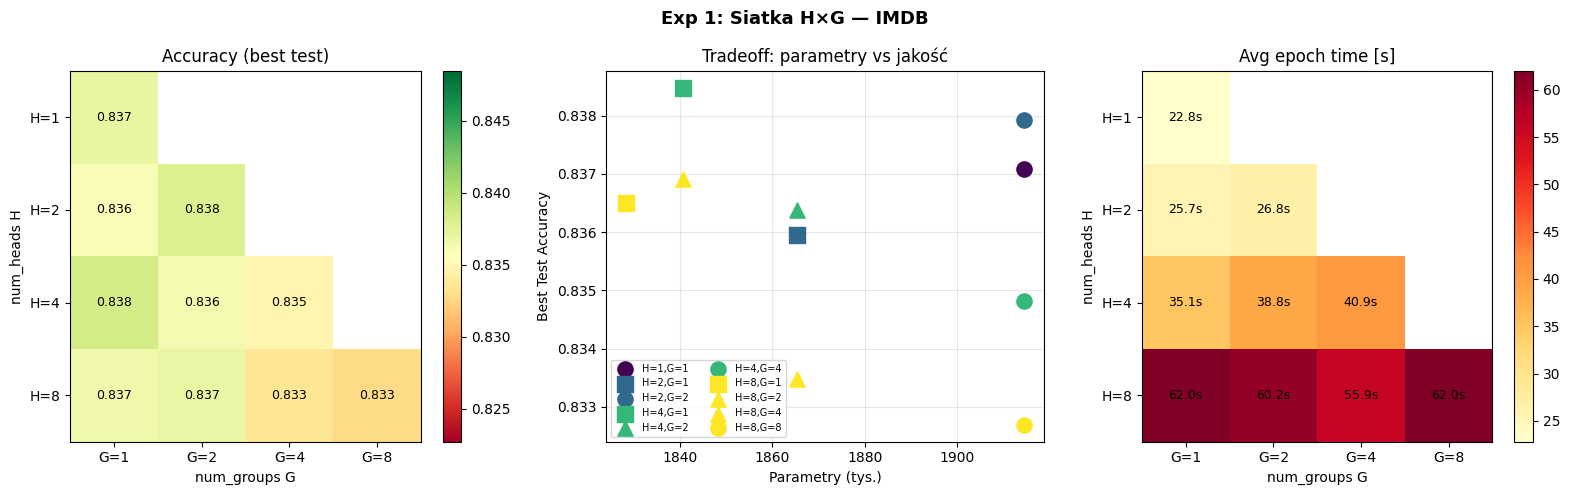

Wykres zapisany.


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

H_list = sorted(set(H for H, G in GRID))
G_list = sorted(set(G for H, G in GRID))

# ── heatmapa accuracy ──────────────────────────────────────────
ax = axes[0]
matrix_acc = np.full((len(H_list), len(G_list)), np.nan)
for i, H in enumerate(H_list):
    for j, G in enumerate(G_list):
        if (H, G) in dict(GRID) or any(h==H and g==G for h,g in GRID):
            if (H, G) in results_grid:
                matrix_acc[i, j] = np.mean([r['best_test_acc'] for r in results_grid[(H, G)]])

im = ax.imshow(matrix_acc, aspect='auto', cmap='RdYlGn',
               vmin=np.nanmin(matrix_acc)-0.01, vmax=np.nanmax(matrix_acc)+0.01)
ax.set_xticks(range(len(G_list))); ax.set_xticklabels([f'G={g}' for g in G_list])
ax.set_yticks(range(len(H_list))); ax.set_yticklabels([f'H={h}' for h in H_list])
ax.set_title('Accuracy (best test)')
ax.set_xlabel('num_groups G'); ax.set_ylabel('num_heads H')
plt.colorbar(im, ax=ax)
for i in range(len(H_list)):
    for j in range(len(G_list)):
        if not np.isnan(matrix_acc[i, j]):
            ax.text(j, i, f'{matrix_acc[i,j]:.3f}', ha='center', va='center', fontsize=9)

# ── params vs accuracy scatter ─────────────────────────────────
ax = axes[1]
for H, G in GRID:
    rs    = results_grid[(H, G)]
    acc   = np.mean([r['best_test_acc'] for r in rs])
    params = rs[0]['num_params'] / 1000
    color = plt.cm.viridis(H_list.index(H) / max(1, len(H_list)-1))
    marker = 'o' if G == H else ('s' if G == 1 else '^')
    label  = f'H={H},G={G}'
    ax.scatter(params, acc, s=120, color=color, marker=marker, zorder=5, label=label)
ax.set_xlabel('Parametry (tys.)')
ax.set_ylabel('Best Test Accuracy')
ax.set_title('Tradeoff: parametry vs jakość')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# ── avg epoch time heatmapa ────────────────────────────────────
ax = axes[2]
matrix_time = np.full((len(H_list), len(G_list)), np.nan)
for i, H in enumerate(H_list):
    for j, G in enumerate(G_list):
        if (H, G) in results_grid:
            matrix_time[i, j] = np.mean([r['avg_epoch_time_s'] for r in results_grid[(H, G)]])

im2 = ax.imshow(matrix_time, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(G_list))); ax.set_xticklabels([f'G={g}' for g in G_list])
ax.set_yticks(range(len(H_list))); ax.set_yticklabels([f'H={h}' for h in H_list])
ax.set_title('Avg epoch time [s]')
ax.set_xlabel('num_groups G'); ax.set_ylabel('num_heads H')
plt.colorbar(im2, ax=ax)
for i in range(len(H_list)):
    for j in range(len(G_list)):
        if not np.isnan(matrix_time[i, j]):
            ax.text(j, i, f'{matrix_time[i,j]:.1f}s', ha='center', va='center', fontsize=9)

plt.suptitle(f'Exp 1: Siatka H×G — IMDB', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'exp1_grid_imdb.png', dpi=150, bbox_inches='tight')
plt.show()
print('Wykres zapisany.')

## 8. Eksperyment 2 — Długość sekwencji × G

H=8 fixed. Hipoteza: GQA bardziej boli przy dłuższych sekwencjach (więcej informacji do zakodowania w K,V).

In [15]:
MAX_LENGTHS = [64, 128, 256, 512]
G_EXP2      = [1, 2, 4, 8]
results_exp2 = defaultdict(dict)  # [max_len][G]

for max_len in MAX_LENGTHS:
    for G in G_EXP2:
        label = 'MHA' if G == 8 else ('MQA' if G == 1 else f'GQA_G{G}')
        print(f'\n=== max_len={max_len}, {label} ===')
        result = run_experiment(
            run_name    = f'exp2_len{max_len}_{label}',
            num_heads   = 8, num_groups = G,
            max_length  = max_len, seed = 42, num_epochs = 20,
            extra_params= {'experiment': 'exp2_seq_length', 'G': G, 'max_length': max_len}
        )
        results_exp2[max_len][G] = result

print('\n=== Eksperyment 2 zakończony ===')


=== max_len=64, MQA ===


[exp2_len64_MQA]: 100%|██████████| 20/20 [05:53<00:00, 17.70s/it, test=0.7447, train=0.8644]



→ exp2_len64_MQA | best=0.7487 (ep12) | params=1,803,842 | 5.5min | inf=9.3ms | mem=67MB | 0.10M tok/s


=== max_len=64, GQA_G2 ===


[exp2_len64_GQA_G2]: 100%|██████████| 20/20 [05:58<00:00, 17.91s/it, test=0.7409, train=0.8701]



→ exp2_len64_GQA_G2 | best=0.7472 (ep7) | params=1,816,130 | 5.5min | inf=9.1ms | mem=67MB | 0.10M tok/s


=== max_len=64, GQA_G4 ===


...


→ exp2_len512_GQA_G2 | best=0.8495 (ep12) | params=1,873,474 | 47.3min | inf=88.2ms | mem=357MB | 0.09M tok/s


=== max_len=512, GQA_G4 ===


[exp2_len512_GQA_G4]: 100%|██████████| 20/20 [53:37<00:00, 160.85s/it, test=0.8456, train=0.9439]



→ exp2_len512_GQA_G4 | best=0.8490 (ep9) | params=1,898,050 | 48.5min | inf=95.8ms | mem=366MB | 0.09M tok/s


=== max_len=512, MHA ===


[exp2_len512_MHA]: 100%|██████████| 20/20 [55:49<00:00, 167.48s/it, test=0.8392, train=0.9488]



→ exp2_len512_MHA | best=0.8443 (ep9) | params=1,947,202 | 55.2min | inf=99.8ms | mem=383MB | 0.08M tok/s


=== Eksperyment 2 zakończony ===


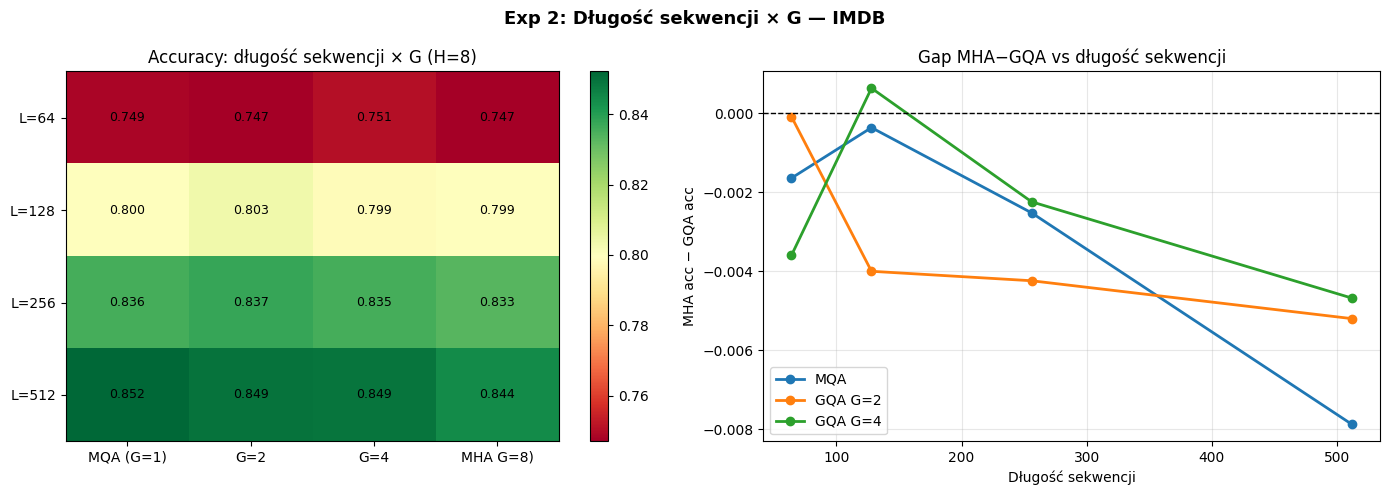

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# heatmapa accuracy
ax = axes[0]
matrix = np.array([[results_exp2[L][G]['best_test_acc'] for G in G_EXP2] for L in MAX_LENGTHS])
im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn')
ax.set_xticks(range(len(G_EXP2))); ax.set_xticklabels(['MQA (G=1)', 'G=2', 'G=4', 'MHA G=8)'])
ax.set_yticks(range(len(MAX_LENGTHS))); ax.set_yticklabels([f'L={L}' for L in MAX_LENGTHS])
ax.set_title('Accuracy: długość sekwencji × G (H=8)')
plt.colorbar(im, ax=ax)
for i, L in enumerate(MAX_LENGTHS):
    for j, G in enumerate(G_EXP2):
        ax.text(j, i, f'{matrix[i,j]:.3f}', ha='center', va='center', fontsize=9)

# gap MHA - GQA
ax = axes[1]
for G in [1, 2, 4]:
    label = 'MQA' if G == 1 else f'GQA G={G}'
    gaps = [results_exp2[L][8]['best_test_acc'] - results_exp2[L][G]['best_test_acc']
            for L in MAX_LENGTHS]
    ax.plot(MAX_LENGTHS, gaps, marker='o', label=label, linewidth=2)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Długość sekwencji'); ax.set_ylabel('MHA acc − GQA acc')
ax.set_title('Gap MHA−GQA vs długość sekwencji')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Exp 2: Długość sekwencji × G — IMDB', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exp2_seq_length_imdb.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Eksperyment 3 — Layer-wise GQA

GQA (G=2) tylko w wybranych warstwach. Pytanie: czy ostatnia warstwa jest bardziej wrażliwa?

In [ ]:
# G=2 w wybranych warstwach; 8=MHA, 2=GQA
LAYER_CONFIGS = {
    'All_MHA':    [8, 8, 8],
    'First_GQA':  [2, 8, 8],
    'Mid_GQA':    [8, 2, 8],
    'Last_GQA':   [8, 8, 2],
    'First2_GQA': [2, 2, 8],
    'Last2_GQA':  [8, 2, 2],
    'All_GQA':    [2, 2, 2],
}

results_exp3 = {}

for cfg_name, G_per_layer in LAYER_CONFIGS.items():
    print(f'\n=== {cfg_name}: warstwy G={G_per_layer} ===')
    accs = []
    for seed in SEEDS:
        layer_configs = [{'num_groups': G} for G in G_per_layer]
        result = run_experiment(
            run_name    = f'exp3_{cfg_name}_seed{seed}',
            num_heads   = 8, num_groups = 2,
            layer_configs = layer_configs,
            max_length  = 256, seed = seed, num_epochs = 20,
            extra_params= {
                'experiment': 'exp3_layer_wise', 'config': cfg_name,
                'G_layer1': G_per_layer[0], 'G_layer2': G_per_layer[1], 'G_layer3': G_per_layer[2],
            }
        )
        accs.append(result)
    results_exp3[cfg_name] = accs

print('\n=== Eksperyment 3 zakończony ===')


=== All_MHA: warstwy G=[8, 8, 8] ===


[exp3_All_MHA_seed42]: 100%|██████████| 20/20 [19:44<00:00, 59.22s/it, test=0.8275, train=0.9398]



→ exp3_All_MHA_seed42 | best=0.8332 (ep10) | params=1,914,434 | 19.3min | inf=33.2ms | mem=147MB | 0.11M tok/s



[exp3_All_MHA_seed123]: 100%|██████████| 20/20 [19:44<00:00, 59.22s/it, test=0.8269, train=0.9421]



→ exp3_All_MHA_seed123 | best=0.8310 (ep8) | params=1,914,434 | 19.2min | inf=33.0ms | mem=147MB | 0.11M tok/s



...

[exp3_Last_GQA_seed777]: 100%|██████████| 20/20 [19:13<00:00, 57.66s/it, test=0.8297, train=0.9412]



→ exp3_Last_GQA_seed777 | best=0.8338 (ep10) | params=1,889,858 | 18.0min | inf=30.8ms | mem=147MB | 0.12M tok/s


=== First2_GQA: warstwy G=[2, 2, 8] ===


[exp3_First2_GQA_seed42]: 100%|██████████| 20/20 [18:32<00:00, 55.62s/it, test=0.8334, train=0.9270]



→ exp3_First2_GQA_seed42 | best=0.8386 (ep10) | params=1,865,282 | 17.2min | inf=29.5ms | mem=147MB | 0.12M tok/s



[exp3_First2_GQA_seed123]:  25%|██▌       | 5/20 [04:37<13:54, 55.65s/it, test=0.8276, train=0.8440]

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cfg_names = list(LAYER_CONFIGS.keys())
means  = [np.mean([r['best_test_acc'] for r in results_exp3[c]]) for c in cfg_names]
stds   = [np.std( [r['best_test_acc'] for r in results_exp3[c]]) for c in cfg_names]
params = [results_exp3[c][0]['num_params'] / 1000 for c in cfg_names]

ax = axes[0]
bars = ax.bar(cfg_names, means, yerr=stds, capsize=5, alpha=0.85, color='steelblue')
bars[0].set_color('#2ecc71')
bars[-1].set_color('#e74c3c')
ax.set_title('Exp 3: Layer-wise GQA (G=2)')
ax.set_ylabel('Best Test Accuracy')
ax.set_ylim(min(means) - 0.02, max(means) + 0.02)
ax.tick_params(axis='x', rotation=20)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
ax.scatter(params, means, s=120, color='steelblue', zorder=5)
for name, x, y in zip(cfg_names, params, means):
    ax.annotate(name, (x, y), textcoords='offset points', xytext=(5, 3), fontsize=8)
ax.set_xlabel('Parametry (tys.)'); ax.set_ylabel('Best Test Accuracy')
ax.set_title('Tradeoff: parametry vs jakość (layer-wise)')
ax.grid(True, alpha=0.3)

plt.suptitle('Exp 3: Layer-wise GQA — IMDB', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exp3_layer_wise_imdb.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Exp 4 — Similarity-based grouping (TODO)

Zostawione na po wynikach siatki H×G.

Plany:
- **AsymGQA**: grupuj głowice Q po podobieństwie aktywacji K
- porównaj z naiwnym grupowaniem dla tego samego H,G
- sprawdź czy głowice naturalne klastry tworzą

## 11. Wizualizacje zbiorcze

In [ ]:
print('=== Podsumowanie wszystkich eksperymentów — IMDB ===')
print('\nExp 1 — siatka H×G:')
print(f'  Kombinacji: {len(GRID)} × {len(SEEDS)} seedy = {len(GRID)*len(SEEDS)} runów')
best_combo = max(GRID, key=lambda hg: np.mean([r['best_test_acc'] for r in results_grid[hg]]))
best_acc   = np.mean([r['best_test_acc'] for r in results_grid[best_combo]])
print(f'  Najlepsza kombinacja: H={best_combo[0]}, G={best_combo[1]} → acc={best_acc:.4f}')

print('\nExp 2 — długość sekwencji:')
for L in MAX_LENGTHS:
    mha_acc = results_exp2[L][8]['best_test_acc']
    mqa_acc = results_exp2[L][1]['best_test_acc']
    print(f'  L={L}: MHA={mha_acc:.4f}, MQA={mqa_acc:.4f}, gap={mha_acc-mqa_acc:.4f}')

print('\nExp 3 — layer-wise GQA:')
for c in cfg_names:
    acc = np.mean([r['best_test_acc'] for r in results_exp3[c]])
    print(f'  {c:15}: {acc:.4f}')
print('\nWszystko zalogowane do MLflow w ./mlruns')